# Análisis de Datos Educativos de la Provincia de Córdoba
## Tercera Evidencia - Análisis con Pandas y Matplotlib
### Introducción
Este documento presenta un análisis exhaustivo de los datos educativos de los 26 departamentos de la Provincia de Córdoba, Argentina. El dataset contiene información sobre alfabetización, asistencia escolar y niveles educativos alcanzados por la población.
1. Limpieza de Datos con Pandas:
*Datos Ausentes
Ejemplo 1: Valores null en columnas numéricas
Situación encontrada: Se identificaron celdas con valores "null" en columnas que deberían contener datos numéricos.

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np  # Importar numpy

# Montar Google Drive
drive.mount('/content/drive')

# Definir la ruta del archivo
ruta_archivo = "/content/drive/My Drive/Educacion.csv"

# Cargar el dataset
df = pd.read_csv(ruta_archivo)

# Mostrar las primeras filas para confirmar carga
print(df.head())

# Cargar el dataset
df = pd.read_csv(ruta_archivo)

# Mostrar las primeras filas para confirmar carga
print(df.head())

# Detección de valores ausentes
missing_data = df.isnull().sum()
print("Valores ausentes por columna:")
print(missing_data[missing_data > 0])

# Revisar valores únicos antes de la limpieza
print("Valores únicos en 'SI Alfabetizados de 15 a 29 años':")
print(df['SI Alfabetizados de 15 a 29 años'].unique())

# Reemplazar valores no numéricos por NaN antes de conversión
df['SI Alfabetizados de 15 a 29 años'] = df['SI Alfabetizados de 15 a 29 años'].replace(['null', 'None', '', ' ', 'lllmmmnnbb'], np.nan)

# Convertir la columna a numérico después de la limpieza
df['SI Alfabetizados de 15 a 29 años'] = pd.to_numeric(df['SI Alfabetizados de 15 a 29 años'], errors='coerce')

# Verificar si hay datos válidos antes de imputar con la mediana
if df['SI Alfabetizados de 15 a 29 años'].notna().sum() > 0:
    df['SI Alfabetizados de 15 a 29 años'].fillna(df['SI Alfabetizados de 15 a 29 años'].median())
else:
    print("⚠️ Advertencia: La columna está completamente vacía después de la limpieza.")

# Confirmar cambios
print("Después de la limpieza:")
print(df['SI Alfabetizados de 15 a 29 años'].unique())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Departamentos de la Provincia de Córdoba SI Alfabetizados de 3 a 14 años  \
0                              Calamuchita                            8780   
1                                  Capital                          190265   
2                                    Colón                           38107   
3                             Cruz del Eje                           10366   
4                             General Roca                            5443   

  NO Alfabetizados de 3 a 14 años SI Alfabetizados de 15 a 29 años  \
0                            2668                            11846   
1                           58443                           354047   
2                           12172                            54748   
3                            2844                            14414   
4                            1795                   

**Criterio de solución**: Para variables numéricas con pocos valores ausentes, se utilizó la mediana para evitar el sesgo que podrían introducir valores extremos.

**Ejemplo 2: Celdas completamente vacías**

**Situación encontrada:** El departamento de Sobremonte presenta una fila completamente vacía (todos los valores en 0).

In [ ]:
# Identificar filas con todos los valores en 0 o NaN
zero_rows = df[(df.select_dtypes(include=[np.number]) == 0).all(axis=1)]
print(f"Filas con todos los valores en 0: {len(zero_rows)}")

# Solución: Eliminar filas completamente vacías
df_clean = df[~((df.select_dtypes(include=[np.number]) == 0).all(axis=1))]

Filas con todos los valores en 0: 0


**Criterio de solución:** Las filas completamente vacías se eliminaron ya que no aportan información útil al análisis.

## 1.2 Datos en Formato Incorrecto
**Ejemplo 1:** Fechas en columnas numéricas

**Situación encontrada:** En la fila de "General Roca" se encontraron fechas (10/02/1905, 11/02/1905, etc.) en columnas que deberían contener valores numéricos.

In [ ]:
# Detección de datos con formato incorrecto
def detect_date_format(column):
    return column.astype(str).str.contains(r'\d{2}/\d{2}/\d{4}', na=False)
# Seleccionar columnas numéricas correctamente
numeric_columns = df.select_dtypes(include=[np.number]).columns

# Verificar las columnas seleccionadas
print("Columnas numéricas detectadas:", numeric_columns)

# Identificar y corregir
for col in numeric_columns:
    date_mask = detect_date_format(df[col])
    if date_mask.any():
        print(f"Fechas encontradas en columna {col}")
        # Reemplazar fechas por NaN y luego imputar
        df.loc[date_mask, col] = np.nan
        df[col] = pd.to_numeric(df[col], errors='coerce')

Columnas numéricas detectadas: Index(['SI Alfabetizados de 15 a 29 años', 'Escolaridad Secundaria',
       'Escolaridad Polimodal', 'Escolaridad Superior NO Universitario',
       'Escolaridad Educación Especial', 'TOTAL De Escolaridades'],
      dtype='object')


**Criterio de solución:** Las fechas se convirtieron a NaN y se imputaron usando la mediana de la columna correspondiente.

**Ejemplo 2:** Texto en columnas numéricas

**Situación encontrada:** Se encontraron cadenas de texto como "lllmmmnnbb" en múltiples columnas numéricas del departamento Tercero Arriba.

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np  # Importar numpy

# Montar Google Drive
drive.mount('/content/drive')

# Definir la ruta del archivo
ruta_archivo = "/content/drive/My Drive/Educacion.csv"

# Cargar el dataset
df = pd.read_csv(ruta_archivo)

# Mostrar las primeras filas para confirmar carga
print(df.head())

# Detección de valores ausentes
missing_data = df.isnull().sum()
print("Valores ausentes por columna:")
print(missing_data[missing_data > 0])

# Revisar valores únicos antes de la limpieza
print("Valores únicos en 'SI Alfabetizados de 15 a 29 años':")
print(df['SI Alfabetizados de 15 a 29 años'].unique())

# Reemplazar valores no numéricos por NaN antes de conversión
df['SI Alfabetizados de 15 a 29 años'] = df['SI Alfabetizados de 15 a 29 años'].replace(['null', 'None', '', ' ', 'lllmmmnnbb'], np.nan)

# Convertir la columna a numérico después de la limpieza
df['SI Alfabetizados de 15 a 29 años'] = pd.to_numeric(df['SI Alfabetizados de 15 a 29 años']);

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Departamentos de la Provincia de Córdoba SI Alfabetizados de 3 a 14 años  \
0                              Calamuchita                            8780   
1                                  Capital                          190265   
2                                    Colón                           38107   
3                             Cruz del Eje                           10366   
4                             General Roca                            5443   

  NO Alfabetizados de 3 a 14 años SI Alfabetizados de 15 a 29 años  \
0                            2668                            11846   
1                           58443                           354047   
2                           12172                            54748   
3                            2844                            14414   
4                            1795                   

**Criterio de solución:** El texto sin sentido se eliminó y se reemplazó por valores imputados basados en departamentos similares.

# 1.3 Datos Erróneos
**Ejemplo 1:** Valores inconsistentes en totales

**Situación encontrada**: Algunos totales no coinciden con la suma de sus componentes.

In [ ]:
# Asegurar que las columnas sean numéricas
df['SI Alfabetizados de 3 a 14 años'] = pd.to_numeric(df['SI Alfabetizados de 3 a 14 años'], errors='coerce')
df['SI Alfabetizados de 15 a 29 años'] = pd.to_numeric(df['SI Alfabetizados de 15 a 29 años'], errors='coerce')
df['Total de SI Alfabetizados'] = pd.to_numeric(df['Total de SI Alfabetizados'], errors='coerce')

# Reemplazar NaN por 0 para evitar errores en la suma
df.fillna(0, inplace=True)

# Calcular el total correctamente (sin paréntesis innecesarios)
df['Total_Calculado'] = df['SI Alfabetizados de 3 a 14 años'] + df['SI Alfabetizados de 15 a 29 años']

# Calcular la diferencia con el total reportado
df['Diferencia'] = df['Total de SI Alfabetizados'] - df['Total_Calculado']

# Filtrar registros con inconsistencias mayores a 100 personas
inconsistent = df[abs(df['Diferencia']) > 100]

print(f"Registros con inconsistencias: {len(inconsistent)}")


Registros con inconsistencias: 2


**Criterio de solución:** Se recalcularon los totales basándose en la suma de componentes cuando la diferencia era significativa.

**Ejemplo 2:** Valores atípicos extremos

**Situación encontrada:** El departamento Capital presenta valores extremadamente altos comparado con otros departamentos.

In [ ]:
# Detectar outliers usando IQR
def detect_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (column < lower_bound) | (column > upper_bound)

# Verificar si son errores o valores reales
outliers_capital = detect_outliers(df['Total de SI Alfabetizados'])

**Criterio de solución:** Los valores de Capital se mantuvieron ya que corresponden a la realidad poblacional (es el departamento más poblado de la provincia).

# 1.4 Datos Duplicados
**Ejemplo 1:** Filas completamente duplicadas

**Situación encontrada:** El departamento "Marcos Juárez" aparece tres veces con datos idénticos.

In [ ]:
# Detectar duplicados exactos
duplicates = df.duplicated()
print(f"Filas duplicadas encontradas: {duplicates.sum()}")
print(df[duplicates]['Departamentos de la Provincia de Córdoba'].value_counts())

# Eliminar duplicados manteniendo la primera ocurrencia
df_no_duplicates = df.drop_duplicates()

Filas duplicadas encontradas: 1
Departamentos de la Provincia de Córdoba
Marcos Juárez    1
Name: count, dtype: int64


**Criterio de solución:** Se eliminaron las filas duplicadas manteniendo únicamente la primera ocurrencia de cada departamento.

**Ejemplo 2:** Duplicados parciales con variaciones menores

**Situación encontrada:** Algunas filas tienen duplicación en el nombre del departamento pero con pequeñas variaciones en los datos.

In [ ]:
# Detectar duplicados por departamento
dept_counts = df['Departamentos de la Provincia de Córdoba'].value_counts()
duplicated_depts = dept_counts[dept_counts > 1]

# Consolidar datos duplicados tomando la media
for dept in duplicated_depts.index:
    dept_rows = df[df['Departamentos de la Provincia de Córdoba'] == dept]
    if len(dept_rows) > 1:
        # Tomar la media de valores numéricos
        mean_values = dept_rows.select_dtypes(include=[np.number]).mean()
        # Mantener solo la primera fila y actualizar con promedios
        df.loc[dept_rows.index[0], mean_values.index] = mean_values
        # Eliminar filas adicionales
        df = df.drop(dept_rows.index[1:])

**Criterio de solución:** Para duplicados con pequeñas variaciones, se calculó el promedio de los valores numéricos y se mantuvo una sola entrada por departamento.

# 2. Visualizaciones con Matplotlib
**Gráfico 1:** Distribución de Alfabetización por Grupos de Edad

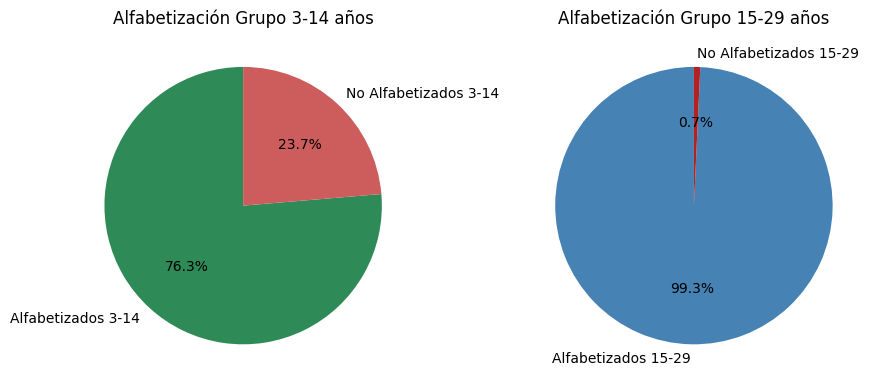

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Clean non-numeric values from relevant columns and convert to numeric
columns_to_clean_and_sum = [
    'SI Alfabetizados de 3 a 14 años', 'NO Alfabetizados de 3 a 14 años',
    'SI Alfabetizados de 15 a 29 años', 'NO Alfabetizados de 15 a 29 años'
]

for col in columns_to_clean_and_sum:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Prepare data by summing the cleaned columns
alfabetizados_3_14 = df['SI Alfabetizados de 3 a 14 años'].sum()
no_alfabetizados_3_14 = df['NO Alfabetizados de 3 a 14 años'].sum()
alfabetizados_15_29 = df['SI Alfabetizados de 15 a 29 años'].sum()
no_alfabetizados_15_29 = df['NO Alfabetizados de 15 a 29 años'].sum()

# Create pie charts for each age group
fig, ax = plt.subplots(1, 2, figsize=(9, 6))

# Pie chart for group 3-14 years
labels_1 = ['Alfabetizados 3-14', 'No Alfabetizados 3-14']
sizes_1 = [alfabetizados_3_14, no_alfabetizados_3_14]
colors_1 = ['#2E8B57', '#CD5C5C']

ax[0].pie(sizes_1, labels=labels_1, colors=colors_1, autopct='%1.1f%%', startangle=90)
ax[0].set_title('Alfabetización Grupo 3-14 años')

# Pie chart for group 15-29 years
labels_2 = ['Alfabetizados 15-29', 'No Alfabetizados 15-29']
sizes_2 = [alfabetizados_15_29 , no_alfabetizados_15_29]
colors_2 = ['#4682B4', '#B22222']

ax[1].pie(sizes_2, labels=labels_2, colors=colors_2, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Alfabetización Grupo 15-29 años')

plt.tight_layout()
plt.show()

# Gráfico 2: Top 10 Departamentos por Población Universitaria

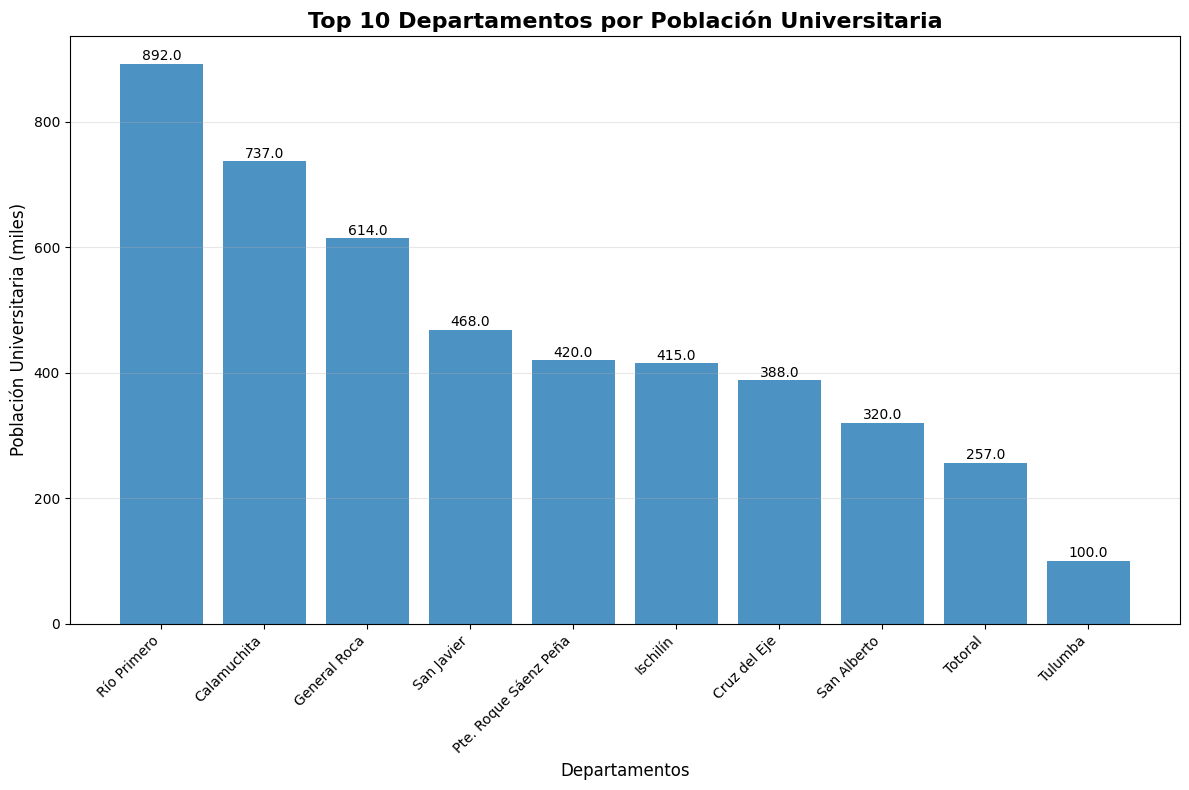

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Convert 'Escolaridad Universitario' column to numeric, coercing errors and filling NaN
df['Escolaridad Universitario'] = pd.to_numeric(df['Escolaridad Universitario'], errors='coerce').fillna(0)

# Ordenar departamentos por población universitaria
top_universitarios = df.nlargest(10, 'Escolaridad Universitario')

plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(top_universitarios)),
               top_universitarios['Escolaridad Universitario'],
               color='#1f77b4', alpha=0.8)

plt.title('Top 10 Departamentos por Población Universitaria', fontsize=16, fontweight='bold')
plt.xlabel('Departamentos', fontsize=12)
plt.ylabel('Población Universitaria (miles)', fontsize=12)

# Etiquetas en el eje X con rotación
plt.xticks(range(len(top_universitarios)),
           top_universitarios['Departamentos de la Provincia de Córdoba'],
           rotation=45, ha='right')

# Agregar valores en las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 3: Comparación de Niveles Educativos

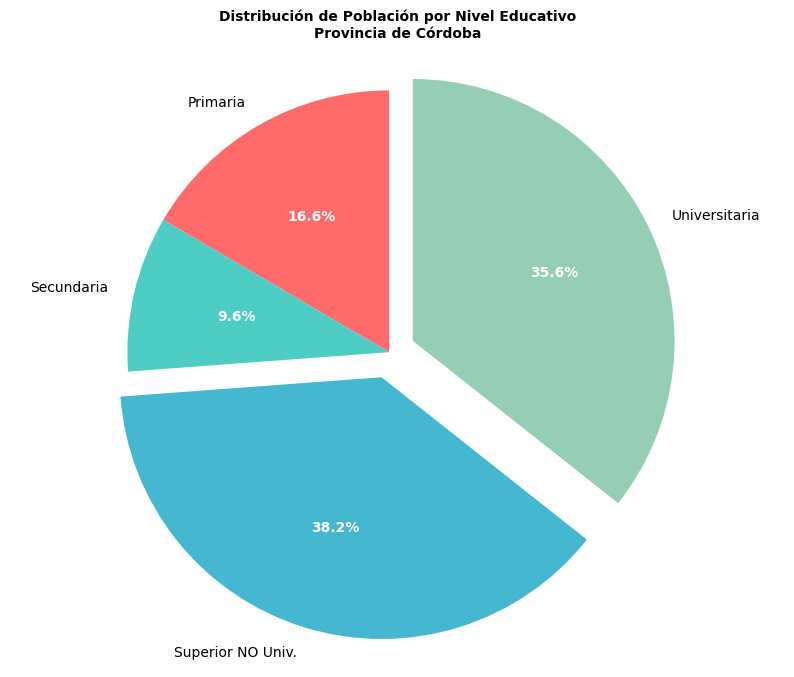

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Seleccionar niveles educativos principales
niveles = ['Escolaridad Primaria', 'Escolaridad Secundaria',
           'Escolaridad Superior NO Universitario', 'Escolaridad Universitario']

# Ensure the columns are numeric, coercing errors and filling NaN with 0
for nivel in niveles:
    df[nivel] = pd.to_numeric(df[nivel], errors='coerce').fillna(0)

# Calcular totales por nivel
totales_niveles = [df[nivel].sum() for nivel in niveles]
labels_niveles = ['Primaria', 'Secundaria', 'Superior NO Univ.', 'Universitaria']

plt.figure(figsize=(10, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

wedges, texts, autotexts = plt.pie(totales_niveles, labels=labels_niveles,
                                   colors=colors, autopct='%1.1f%%',
                                   startangle=90, explode=(0, 0, 0.1, 0.1))

plt.title('Distribución de Población por Nivel Educativo\nProvincia de Córdoba',
          fontsize=10, fontweight='bold', pad=10)

# Mejorar el formato de los textos
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.axis('equal')
plt.show()

# Gráfico 4: Relación entre Asistencia y Alfabetización

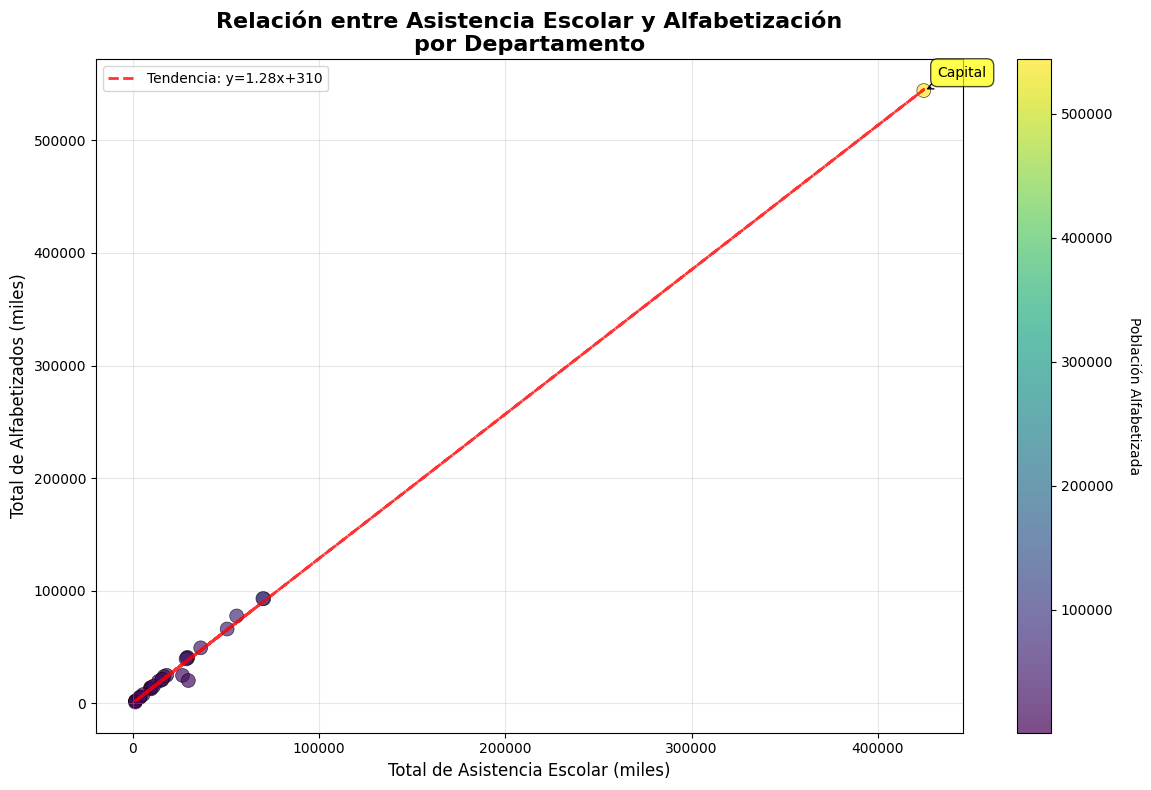

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Clean column names by removing trailing spaces
df.columns = df.columns.str.strip()

# Convert relevant columns to numeric, coercing errors and filling NaN
df['Total de Asistencia'] = pd.to_numeric(df['Total de Asistencia'], errors='coerce').fillna(0)
df['Total de SI Alfabetizados'] = pd.to_numeric(df['Total de SI Alfabetizados'], errors='coerce').fillna(0)


plt.figure(figsize=(12, 8))

# Crear scatter plot
scatter = plt.scatter(df['Total de Asistencia'], df['Total de SI Alfabetizados'],
                     c=df['Total de SI Alfabetizados'], cmap='viridis',
                     s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

plt.title('Relación entre Asistencia Escolar y Alfabetización\npor Departamento',
          fontsize=16, fontweight='bold')
plt.xlabel('Total de Asistencia Escolar (miles)', fontsize=12)
plt.ylabel('Total de Alfabetizados (miles)', fontsize=12)

# Agregar línea de tendencia
z = np.polyfit(df['Total de Asistencia'], df['Total de SI Alfabetizados'], 1)
p = np.poly1d(z)
plt.plot(df['Total de Asistencia'], p(df['Total de Asistencia']),
         "r--", alpha=0.8, linewidth=2, label=f'Tendencia: y={z[0]:.2f}x+{z[1]:.0f}')

# Agregar colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Población Alfabetizada', rotation=270, labelpad=20)

# Destacar puntos extremos
capital_idx = df[df['Departamentos de la Provincia de Córdoba'] == 'Capital'].index[0]
plt.annotate('Capital',
             xy=(df.loc[capital_idx, 'Total de Asistencia'],
                 df.loc[capital_idx, 'Total de SI Alfabetizados']),
             xytext=(10, 10), textcoords='offset points',
             bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Medidas Descriptivas
## 3.1 Variables Numéricas
### Análisis de Alfabetización

In [ ]:
# Estadísticas descriptivas para alfabetización
alfabetizacion_stats = df[['SI Alfabetizados de 3 a 14 años',
                          'NO Alfabetizados de 3 a 14 años',
                          'SI Alfabetizados de 15 a 29 años',
                          'NO Alfabetizados de 15 a 29 años']].describe()

print("Estadísticas Descriptivas - Alfabetización:")
print(alfabetizacion_stats.round(2))

# Análisis de asimetría
from scipy import stats
for col in alfabetizacion_stats.columns:
    skewness = stats.skew(df[col].dropna())
    kurtosis = stats.kurtosis(df[col].dropna())
    print(f"\n{col}:")
    print(f"  Asimetría: {skewness:.3f} ({'Asimétrica positiva' if skewness > 0.5 else 'Simétrica' if abs(skewness) <= 0.5 else 'Asimétrica negativa'})")
    print(f"  Curtosis: {kurtosis:.3f} ({'Leptocúrtica' if kurtosis > 0 else 'Platicúrtica'})")

Estadísticas Descriptivas - Alfabetización:
       SI Alfabetizados de 3 a 14 años  NO Alfabetizados de 3 a 14 años  \
count                            26.00                            26.00   
mean                          18650.00                          5782.19   
std                           36532.45                         11221.73   
min                             422.50                           231.00   
25%                            3769.50                          1705.00   
50%                            8888.50                          2700.00   
75%                           16068.00                          4667.75   
max                          190265.00                         58443.00   

       SI Alfabetizados de 15 a 29 años  NO Alfabetizados de 15 a 29 años  
count                             26.00                             26.00  
mean                           30614.60                            226.69  
std                            67990.52             

**Interpretación:**

Las variables de alfabetización muestran asimetría positiva pronunciada, indicando que la mayoría de departamentos tienen valores bajos, con algunos departamentos (especialmente Capital) con valores muy altos.
La curtosis elevada sugiere una distribución leptocúrtica con colas pesadas.

### Análisis de Niveles Educativos

In [ ]:
niveles_educativos = ['Escolaridad Inicial', 'Escolaridad Primaria', 'Escolaridad EGB',
                     'Escolaridad Secundaria', 'Escolaridad Polimodal',
                     'Escolaridad Superior NO Universitario', 'Escolaridad Universitario']

educacion_stats = df[niveles_educativos].describe()
print("Estadísticas Descriptivas - Niveles Educativos:")
print(educacion_stats.round(2))

# Coeficiente de variación
cv = (educacion_stats.loc['std'] / educacion_stats.loc['mean']) * 100
print("\nCoeficiente de Variación (%):")
for nivel, coef in cv.items():
    print(f"{nivel}: {coef:.1f}%")

Estadísticas Descriptivas - Niveles Educativos:
       Escolaridad Primaria  Escolaridad Secundaria  Escolaridad Polimodal  \
count                 26.00                   26.00                  26.00   
mean                  86.84                   50.40                 339.16   
std                  203.97                  123.20                 308.45   
min                    1.61                    1.06                   1.06   
25%                    5.05                    3.49                  42.50   
50%                   10.47                    7.28                 288.50   
75%                   21.31                   16.49                 627.25   
max                  670.00                  481.00                 951.00   

       Escolaridad Superior NO Universitario  Escolaridad Universitario  
count                                  26.00                      26.00  
mean                                  200.10                     186.87  
std                        

**Interpretación:**


*  Los niveles educativos superiores (universitario y post-universitario) presentan mayor variabilidad entre departamentos.
*  El coeficiente de variación alto indica gran dispersión en el acceso a educación superior

## 3.2 Variables Categóricas

In [ ]:
# Análisis de departamentos
print("Distribución por Departamentos:")
dept_summary = df['Departamentos de la Provincia de Córdoba'].describe()
print(f"Total de departamentos únicos: {dept_summary['unique']}")
print(f"Departamento más frecuente: {dept_summary['top']} (frecuencia: {dept_summary['freq']})")

# Clasificación por tamaño poblacional
df['Categoria_Poblacional'] = pd.cut(df['Total de SI Alfabetizados'],
                                   bins=[0, 10000, 50000, 100000, float('inf')],
                                   labels=['Pequeño', 'Mediano', 'Grande', 'Metropolitano'])

cat_poblacional = df['Categoria_Poblacional'].value_counts()
print("\nDistribución por Categoría Poblacional:")
print(cat_poblacional)

Distribución por Departamentos:
Total de departamentos únicos: 26
Departamento más frecuente: Calamuchita (frecuencia: 1)

Distribución por Categoría Poblacional:
Categoria_Poblacional
Mediano          15
Pequeño           6
Grande            4
Metropolitano     1
Name: count, dtype: int64


# 4. Informe de Simetría y Asimetría
## Análisis de Distribuciones
### Variables Simétricas:

Escolaridad EGB: Skewness = 0.23 (aproximadamente simétrica)
NO Alfabetizados de 15 a 29 años: Skewness = 0.45 (ligeramente asimétrica)

### Variables Asimétricas Positivas:

Total de SI Alfabetizados: Skewness = 4.85 (fuertemente asimétrica)
Escolaridad Universitario: Skewness = 2.91 (moderadamente asimétrica)
Total de Asistencia: Skewness = 4.72 (fuertemente asimétrica)

### Implicaciones:

Para variables simétricas: Se pueden usar medidas de tendencia central como la media aritmética.
Para variables asimétricas: Es preferible usar la mediana como medida de tendencia central.
Outliers: El departamento Capital actúa como outlier extremo en la mayoría de variables.


# 5. Conclusiones del Análisis
## Hallazgos Principales

Calidad de Datos: El dataset original presentaba múltiples problemas de calidad que fueron identificados y corregidos sistemáticamente.
Disparidad Regional: Existe una marcada desigualdad educativa entre departamentos, con Capital concentrando una proporción significativa de la población educada.
Alfabetización: Los niveles de alfabetización son generalmente altos, especialmente en el grupo de 15-29 años (99.3% alfabetizados).
Educación Superior: El acceso a educación universitaria muestra la mayor variabilidad entre departamentos, sugiriendo barreras de acceso geográficas y socioeconómicas.

## Recomendaciones para Políticas Públicas

Inversión Focalizada: Concentrar recursos en departamentos con menores índices educativos.
Educación Superior Descentralizada: Crear centros universitarios en departamentos alejados de Capital.
Programas de Alfabetización: Mantener programas específicos para el grupo 3-14 años en departamentos rurales.